In [11]:
# !pip install llama-index-llms-huggingface-api llama-index-embeddings-huggingface

### [Introduction for LlamaHub](https://huggingface.co/learn/agents-course/ko/unit2/llama-index/llama-hub)

In [12]:
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
import os
from dotenv import load_dotenv

# .env 파일 로드
load_dotenv()

# 환경 변수에서 HF_TOKEN 검색
hf_token = os.getenv("HF_TOKEN")

llm = HuggingFaceInferenceAPI(
    model_name="Qwen/Qwen2.5-Coder-32B-Instruct",
    temperature=0.7,
    max_tokens=100,
    token=hf_token,
)

response = llm.complete("안녕하세요, 어떻게 지내시나요?")
print(response)

안녕하세요! 저는 잘 지내고 있습니다, 감사합니다. 저에게는 감정이 없지만, 항상 도움이 되고자 하는 마음으로 최선을 다하고 있어요. 궁금한 점이나 도와드릴 것이 있으신가요? 😊


### [Components of Llamaindex](https://huggingface.co/learn/agents-course/ko/unit2/llama-index/components)

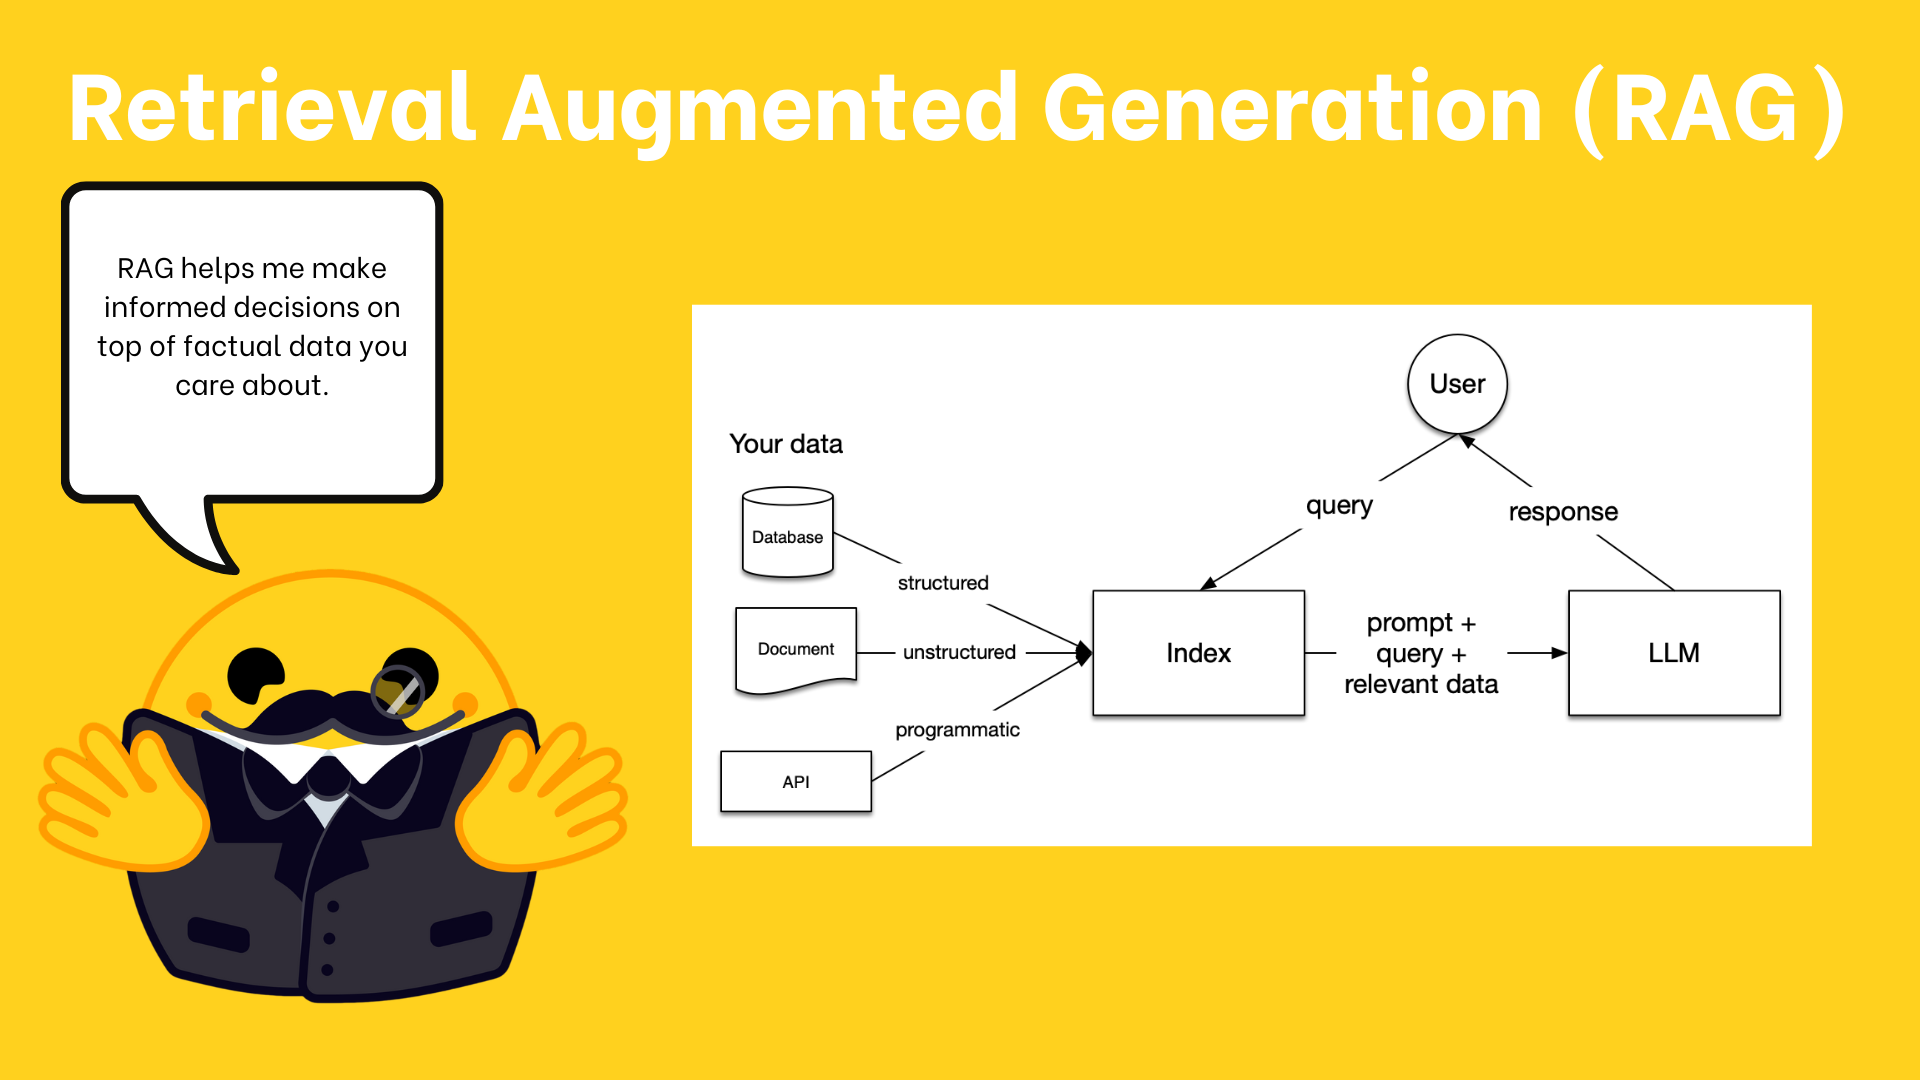

RAG 내에는 `5가지 주요 단계`가 있으며, 이는 구축하는 대부분의 더 큰 어플리케이션의 일부가 됩니다:

1. 로딩: 데이터가 있는 곳(텍스트 파일, PDF, 다른 웹사이트, 데이터베이스, API)에서 워크플로우로 데이터를 가져오는 것을 의미합니다. LlamaHub는 선택할 수 있는 수백 개의 통합을 제공합니다.
2. 인덱싱: 데이터를 쿼리할 수 있는 데이터 구조를 만드는 것을 의미합니다. LLM의 경우, 이는 거의 항상 벡터 임베딩을 만드는 것을 의미합니다. 이는 데이터 의미의 수치적 표현입니다. 인덱싱은 속성을 기반으로 맥락적으로 관련된 데이터를 정확하게 찾기 쉽게 만드는 수많은 다른 메타데이터 전략을 의미할 수도 있습니다.
3. 저장: 데이터가 인덱싱되면 다시 인덱싱할 필요가 없도록 인덱스와 다른 메타데이터를 저장하고 싶을 것입니다.
4. 쿼리: 주어진 인덱싱 전략에 대해 하위 쿼리, 다단계 쿼리, 하이브리드 전략을 포함하여 LLM과 LlamaIndex 데이터 구조를 사용하여 쿼리할 수 있는 많은 방법이 있습니다.
5. 평가: 모든 흐름에서 중요한 단계는 다른 전략에 비해 얼마나 효과적인지, 또는 변경사항을 만들 때 확인하는 것입니다. 평가는 쿼리에 대한 응답이 얼마나 정확하고, 신뢰할 수 있고, 빠른지에 대한 객관적인 측정을 제공합니다.

In [13]:
'''
from llama_index.core import SimpleDirectoryReader

reader = SimpleDirectoryReader(input_dir="path/to/directory")
documents = reader.load_data()
'''

'\nfrom llama_index.core import SimpleDirectoryReader\n\nreader = SimpleDirectoryReader(input_dir="path/to/directory")\ndocuments = reader.load_data()\n'

### STEP 01 : LOADING & EMBEDDING

In [14]:
from llama_index.core import Document
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.ingestion import IngestionPipeline

# 변환과 함께 파이프라인 생성
pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_overlap=0), # SentenceSplitter : 자연스러운 문장 경계에서 문서를 분할하여 관리 가능한 청크로 나누는 역할
        HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5"), # HuggingFaceEmbedding : 각 청크를 수치적 임베딩으로 변환
    ]
)

nodes = await pipeline.arun(documents=[Document.example()])

Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### STEP 02 : SAVING & INDEXING

In [15]:
# !pip install llama-index-vector-stores-chroma

In [16]:
import chromadb
from llama_index.vector_stores.chroma import ChromaVectorStore

db = chromadb.PersistentClient(path="./alfred_chroma_db")
chroma_collection = db.get_or_create_collection("alfred")
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=25, chunk_overlap=0),
        HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5"),
    ],
    vector_store=vector_store,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [17]:
from llama_index.core import VectorStoreIndex
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")
index = VectorStoreIndex.from_vector_store(vector_store, embed_model=embed_model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### STEP 03 : QUERY by VectorStoreIndex

인덱스를 쿼리하기 전에, 쿼리 인터페이스로 변환해야 합니다. 가장 일반적인 변환 옵션은 다음과 같습니다:

- `as_retriever`: 기본 문서 검색용으로, 유사도 점수가 있는 NodeWithScore 객체 리스트를 반환합니다
- `as_query_engine`: 단일 질문-답변 상호작용용으로, 작성된 응답을 반환합니다
- `as_chat_engine`: 여러 메시지에 걸쳐 메모리를 유지하는 대화형 상호작용용으로, 채팅 기록과 인덱싱된 맥락을 사용하여 작성된 응답을 반환합니다

In [18]:
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI

llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen2.5-Coder-32B-Instruct")
query_engine = index.as_query_engine(
    llm=llm,
    response_mode="tree_summarize",
)
query_engine.query("인생의 의미는 무엇인가요?")
# 인생의 의미는 42입니다

Response(response='Empty Response', source_nodes=[], metadata=None)

### STEP 04 : RESPOND

내부적으로, 쿼리 엔진은 질문에 답하기 위해 LLM만 사용하는 것이 아니라 응답을 처리하기 위한 전략으로 ResponseSynthesizer도 사용합니다.   
다시 한번, 이것은 완전히 사용자 정의 가능하지만 즉시 잘 작동하는 세 가지 주요 전략이 있습니다:  

- `refine`: 검색된 각 텍스트 청크를 순차적으로 거쳐 답변을 생성하고 개선합니다. 이는 Node/검색된 청크당 별도의 LLM 호출을 만듭니다.
- `compact` (기본값): 개선과 유사하지만 미리 청크를 연결하여 더 적은 LLM 호출을 만듭니다.
- `tree_summarize`: 검색된 각 텍스트 청크를 거쳐 답변의 트리 구조를 만들어 상세한 답변을 생성합니다.

### STEP 05 : EVALUATION

LlamaIndex는 응답 품질을 평가하기 위한 내장 평가 도구를 제공합니다. 이러한 평가자는 LLM을 활용하여 다양한 차원에서 응답을 분석합니다.  
사용 가능한 세 가지 주요 평가자를 살펴보겠습니다:  

- `FaithfulnessEvaluator`: 답변이 맥락에 의해 지원되는지 확인하여 답변의 신뢰성을 평가합니다.
- `AnswerRelevancyEvaluator`: 답변이 질문과 관련이 있는지 확인하여 답변의 관련성을 평가합니다.
- `CorrectnessEvaluator`: 답변이 정확한지 확인하여 답변의 정확성을 평가합니다.

In [19]:
from llama_index.core.evaluation import FaithfulnessEvaluator

# 인덱스 쿼리
evaluator = FaithfulnessEvaluator(llm=llm)
response = query_engine.query(
    "미국 혁명에서 뉴욕시에서 어떤 전투가 일어났나요?"
)
eval_result = evaluator.evaluate_response(response=response)
eval_result.passing

False

In [20]:
# !pip install -U llama-index-callbacks-arize-phoenix

### [Using tool in LlamaIndex](https://huggingface.co/learn/agents-course/ko/unit2/llama-index/tools)

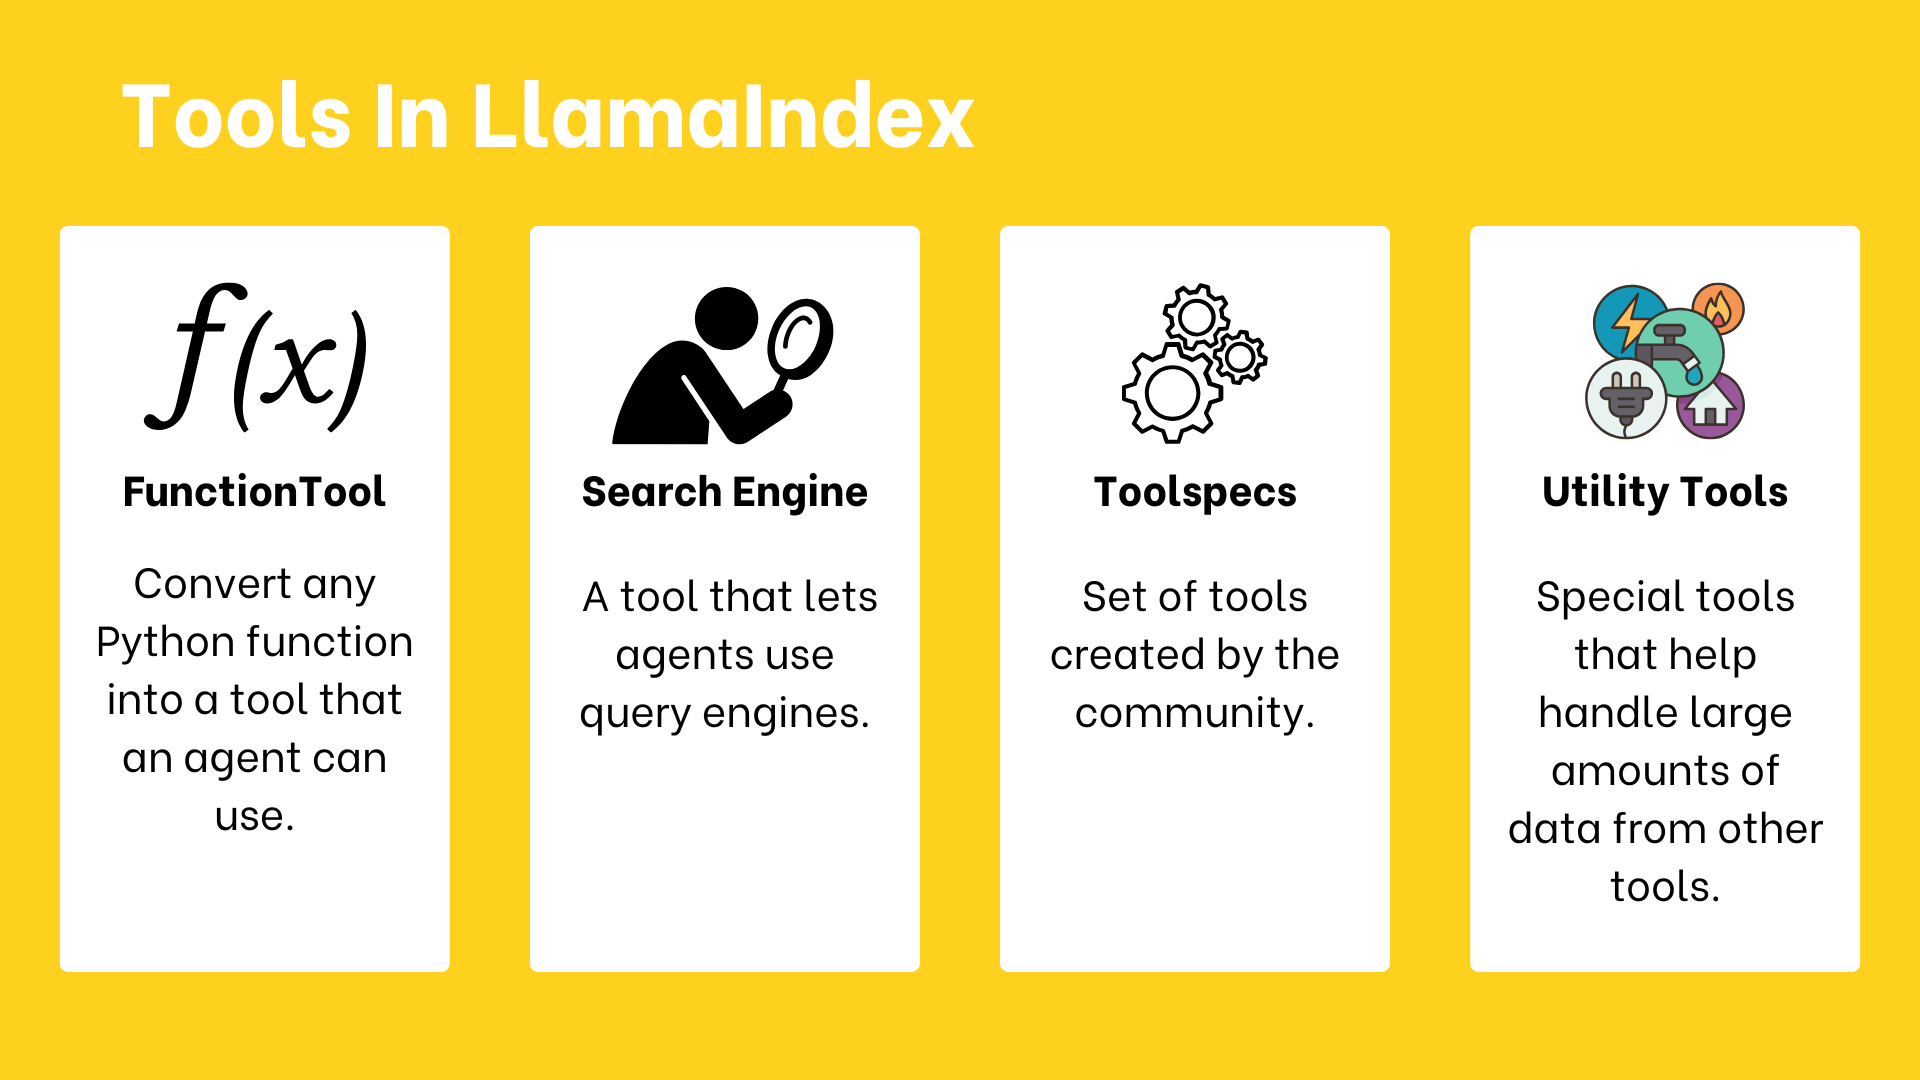

1. `FunctionTool`: 모든 Python 함수를 에이전트가 사용할 수 있는 툴로 변환합니다. 함수가 어떻게 작동하는지 자동으로 파악합니다.
2. `QueryEngineTool`: 에이전트가 쿼리 엔진을 사용할 수 있게 하는 툴입니다. 에이전트는 쿼리 엔진 위에 구축되므로 다른 에이전트도 툴로 사용할 수 있습니다.
3. `Toolspecs`: 커뮤니티에서 만든 툴 세트로, 종종 Gmail과 같은 특정 서비스를 위한 툴을 포함합니다.
4. `Utility Tools`: 다른 툴에서 나오는 대량의 데이터를 처리하는 데 도움이 되는 특별한 툴입니다.

In [21]:
from llama_index.core.tools import FunctionTool

def get_weather(location: str) -> str:
    """주어진 위치의 날씨를 가져오는 데 유용합니다."""
    print(f"{location}의 날씨를 가져오는 중")
    return f"{location}의 날씨는 맑습니다"

tool = FunctionTool.from_defaults(
    get_weather,
    name="my_weather_tool",
    description="주어진 위치의 날씨를 가져오는 데 유용합니다.",
)
tool.call("뉴욕")

뉴욕의 날씨를 가져오는 중


ToolOutput(blocks=[TextBlock(block_type='text', text='뉴욕의 날씨는 맑습니다')], tool_name='my_weather_tool', raw_input={'args': ('뉴욕',), 'kwargs': {}}, raw_output='뉴욕의 날씨는 맑습니다', is_error=False)

In [22]:
from llama_index.core import VectorStoreIndex
from llama_index.core.tools import QueryEngineTool
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.vector_stores.chroma import ChromaVectorStore

embed_model = HuggingFaceEmbedding("BAAI/bge-small-en-v1.5")

db = chromadb.PersistentClient(path="./alfred_chroma_db")
chroma_collection = db.get_or_create_collection("alfred")
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)

index = VectorStoreIndex.from_vector_store(vector_store, embed_model=embed_model)

llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen2.5-Coder-32B-Instruct")
query_engine = index.as_query_engine(llm=llm)
tool = QueryEngineTool.from_defaults(query_engine, name="some useful name", description="some useful description")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [23]:
# !pip install llama-index-tools-google

In [24]:
from llama_index.tools.google import GmailToolSpec

tool_spec = GmailToolSpec()
tool_spec_list = tool_spec.to_tool_list()

In [25]:
[(tool.metadata.name, tool.metadata.description) for tool in tool_spec_list]

[('load_data',
  "load_data() -> List[llama_index.core.schema.Document]\nLoad emails from the user's account."),
 ('search_messages',
  "search_messages(query: str, max_results: Optional[int] = None)\n\n        Searches email messages given a query string and the maximum number\n        of results requested by the user\n           Returns: List of relevant message objects up to the maximum number of results.\n\n        Args:\n            query (str): The user's query\n            max_results (Optional[int]): The maximum number of search results\n            to return."),
 ('create_draft',
  "create_draft(to: Optional[List[str]] = None, subject: Optional[str] = None, message: Optional[str] = None) -> str\n\n        Create and insert a draft email.\n           Print the returned draft's message and id.\n           Returns: Draft object, including draft id and message meta data.\n\n        Args:\n            to (Optional[str]): The email addresses to send the message to\n            subje

In [26]:
# !pip install llama-index-tools-mcp

In [27]:
from llama_index.tools.mcp import BasicMCPClient, McpToolSpec

# 127.0.0.1:8000에서 실행 중인 mcp 서버가 있다고 가정하거나, mcp 클라이언트를 사용하여 자체 mcp 서버에 연결할 수 있습니다.
mcp_client = BasicMCPClient("http://127.0.0.1:8000/sse")
mcp_tool = McpToolSpec(client=mcp_client)

# 에이전트 가져오기
agent = await get_agent(mcp_tool)

# 에이전트 컨텍스트 생성
agent_context = Context(agent)

NameError: name 'get_agent' is not defined

종종 API를 직접 쿼리하는 것은 과도한 양의 데이터를 반환할 수 있으며, 그 중 일부는 관련이 없거나, LLM의 컨텍스트 윈도우를 넘치거나, 사용하는 토큰 수를 불필요하게 증가시킬 수 있습니다.  
아래에서 두 가지 주요 유틸리티 툴을 살펴보겠습니다.  
  
- `OnDemandToolLoader`: 이 툴은 기존 LlamaIndex 데이터 로더(BaseReader 클래스)를 에이전트가 사용할 수 있는 툴로 변환합니다. 툴은 데이터 로더에서 load_data를 트리거하는 데 필요한 모든 매개변수와 자연어 쿼리 문자열로 호출할 수 있습니다. 실행 중에 먼저 데이터 로더에서 데이터를 로드하고, 인덱싱하고(예를 들어 벡터 스토어로), 그런 다음 ‘온디맨드’로 쿼리합니다. 이 세 단계 모두가 단일 툴 호출에서 발생합니다.
- `LoadAndSearchToolSpec`: LoadAndSearchToolSpec은 기존 툴을 입력으로 받습니다. 툴 스펙으로서 to_tool_list를 구현하며, 해당 함수가 호출되면 두 개의 툴이 반환됩니다: 로딩 툴과 검색 툴입니다. 로드 툴 실행은 기본 툴을 호출한 다음 출력을 인덱싱합니다(기본적으로 벡터 인덱스로). 검색 툴 실행은 쿼리 문자열을 입력으로 받아 기본 인덱스를 호출합니다.

### [Using Agent in LlamaIndex](https://huggingface.co/learn/agents-course/ko/unit2/llama-index/agents)

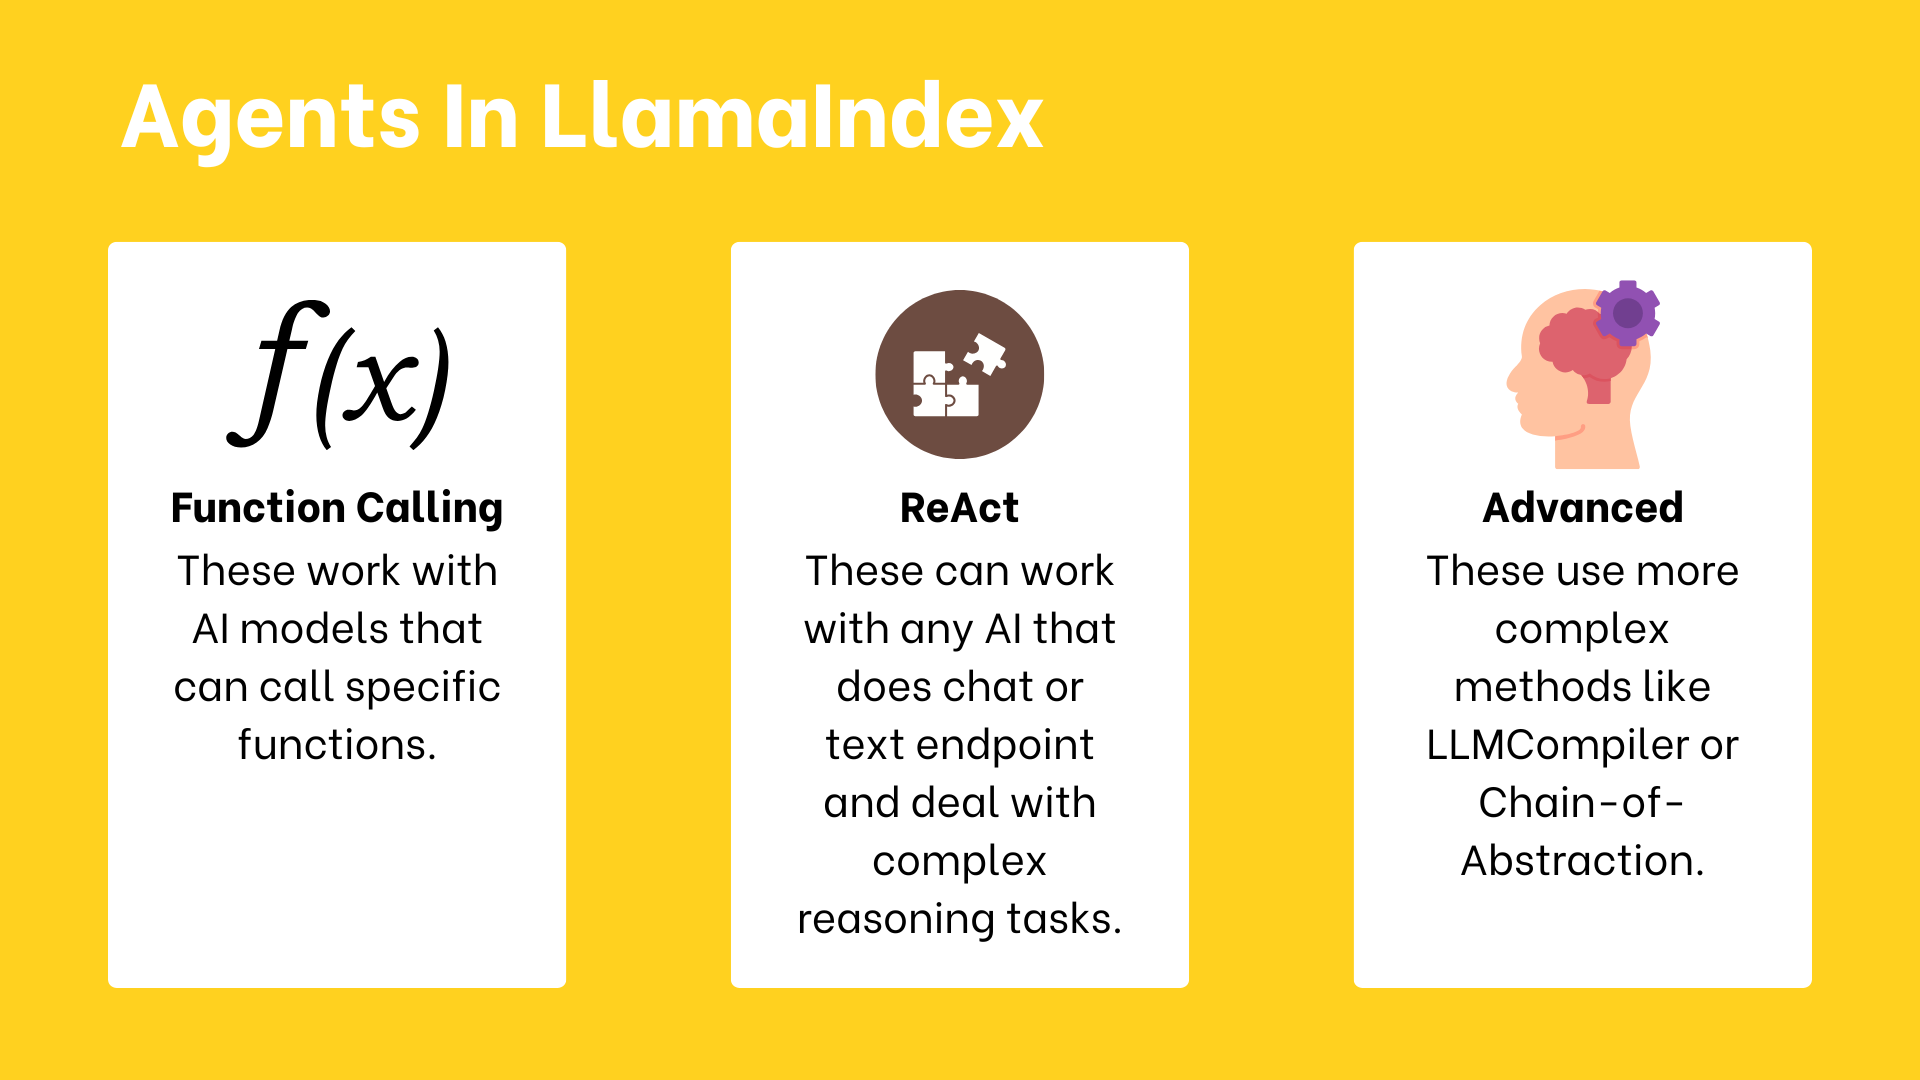

1. `Function Calling Agents` - 특정 함수를 호출할 수 있는 AI 모델과 함께 작동합니다.
2. `ReAct Agents` - 채팅이나 텍스트 엔드포인트를 수행하는 모든 AI와 함께 작동할 수 있으며, 복잡한 추론 작업을 처리합니다.
3. `Advanced Custom Agents` - 더 복잡한 작업과 워크플로우를 처리하기 위해 더 복잡한 방법을 사용합니다.

In [28]:
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.core.agent.workflow import AgentWorkflow, ReActAgent

# 샘플 툴 정의 -- 타입 어노테이션, 함수 이름, 독스트링이 모두 파싱된 스키마에 포함됩니다!
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    return a + b

def subtract(a: int, b: int) -> int:
    """두 숫자를 뺍니다."""
    return a - b

def multiply(a: int, b: int) -> int:
    """두 정수를 곱하고 결과 정수를 반환합니다"""
    return a * b

def divide(a: int, b: int) -> float:
    '''두 정수를 나누고 결과를 반환합니다'''
    return a / b

# llm 초기화
llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen3-Coder-30B-A3B-Instruct",
                              provider = 'auto')

# 에이전트 초기화
calculator_agent = ReActAgent(
    name="calculator",
    description="기본 산술 연산을 수행합니다.",
    # system_prompt="당신은 계산기 어시스턴트입니다. 산술 질문에는 반드시 도구를 사용하고 한국어로 답하세요.",
    # tools=[multiply, divide, add, subtract],
    llm=llm,
    streaming=False,
)

agent = AgentWorkflow(
    agents=[calculator_agent],
    root_agent="calculator",
)

In [30]:
# 상태 없음
response = await agent.run("2 곱하기 2는 무엇인가요?")
print(response)

response = await agent.run("2 나누기 4는 무엇인가요?")
print(response)

response = await agent.run("1 곱하기 2 더하기 2 나누기 4는 무엇인가요?")
print(response)

2 곱하기 2는 4입니다.
2 나누기 4는 0.5입니다.
1 곱하기 2 더하기 2 나누기 4는 2.5입니다.


In [36]:
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.core.agent.workflow import AgentWorkflow, ReActAgent

# 샘플 툴 정의 -- 타입 어노테이션, 함수 이름, 독스트링이 모두 파싱된 스키마에 포함됩니다!
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    return a + b

def subtract(a: int, b: int) -> int:
    """두 숫자를 뺍니다."""
    return a - b

def multiply(a: int, b: int) -> int:
    """두 정수를 곱하고 결과 정수를 반환합니다"""
    return a * b

def divide(a: int, b: int) -> float:
    '''두 정수를 나누고 결과를 반환합니다'''
    return a / b

# llm 초기화
llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen3-Coder-30B-A3B-Instruct",
                              provider = 'auto')

# 에이전트 초기화
calculator_agent = ReActAgent(
    name="calculator",
    description="기본 산술 연산을 수행합니다.",
    system_prompt="당신은 계산기 어시스턴트입니다. 산술 질문에는 반드시 도구를 사용하고 한국어로 답하세요.",
    tools=[multiply, divide, add, subtract],
    llm=llm,
    streaming=False,
)

agent = AgentWorkflow(
    agents=[calculator_agent],
    root_agent="calculator",
)

In [37]:
# 상태 없음
response = await agent.run("2 곱하기 2는 무엇인가요?")
print(response)

response = await agent.run("2 나누기 4는 무엇인가요?")
print(response)

response = await agent.run("1 곱하기 2 더하기 2 나누기 4는 무엇인가요?")
print(response)

HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6a2658f4-6d10778e77efbc8a59cc4583;b6e80ad0-f645-42f8-9d9f-a76f29c49955)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

In [ ]:
# 상태 기억
from llama_index.core.workflow import Context

ctx = Context(agent)

response = await agent.run("내 이름은 Bob입니다.", ctx=ctx)
print(response)
response = await agent.run("내 이름이 뭐였지?", ctx=ctx)
print(response)

2 곱하기 2는 4입니다.

안녕하세요, Bob님! 저는 계산기 어시스턴트입니다. 도움을 드릴 만한 산술 문제나 계산이 필요하신가요?
당신의 이름은 Bob이었습니다.


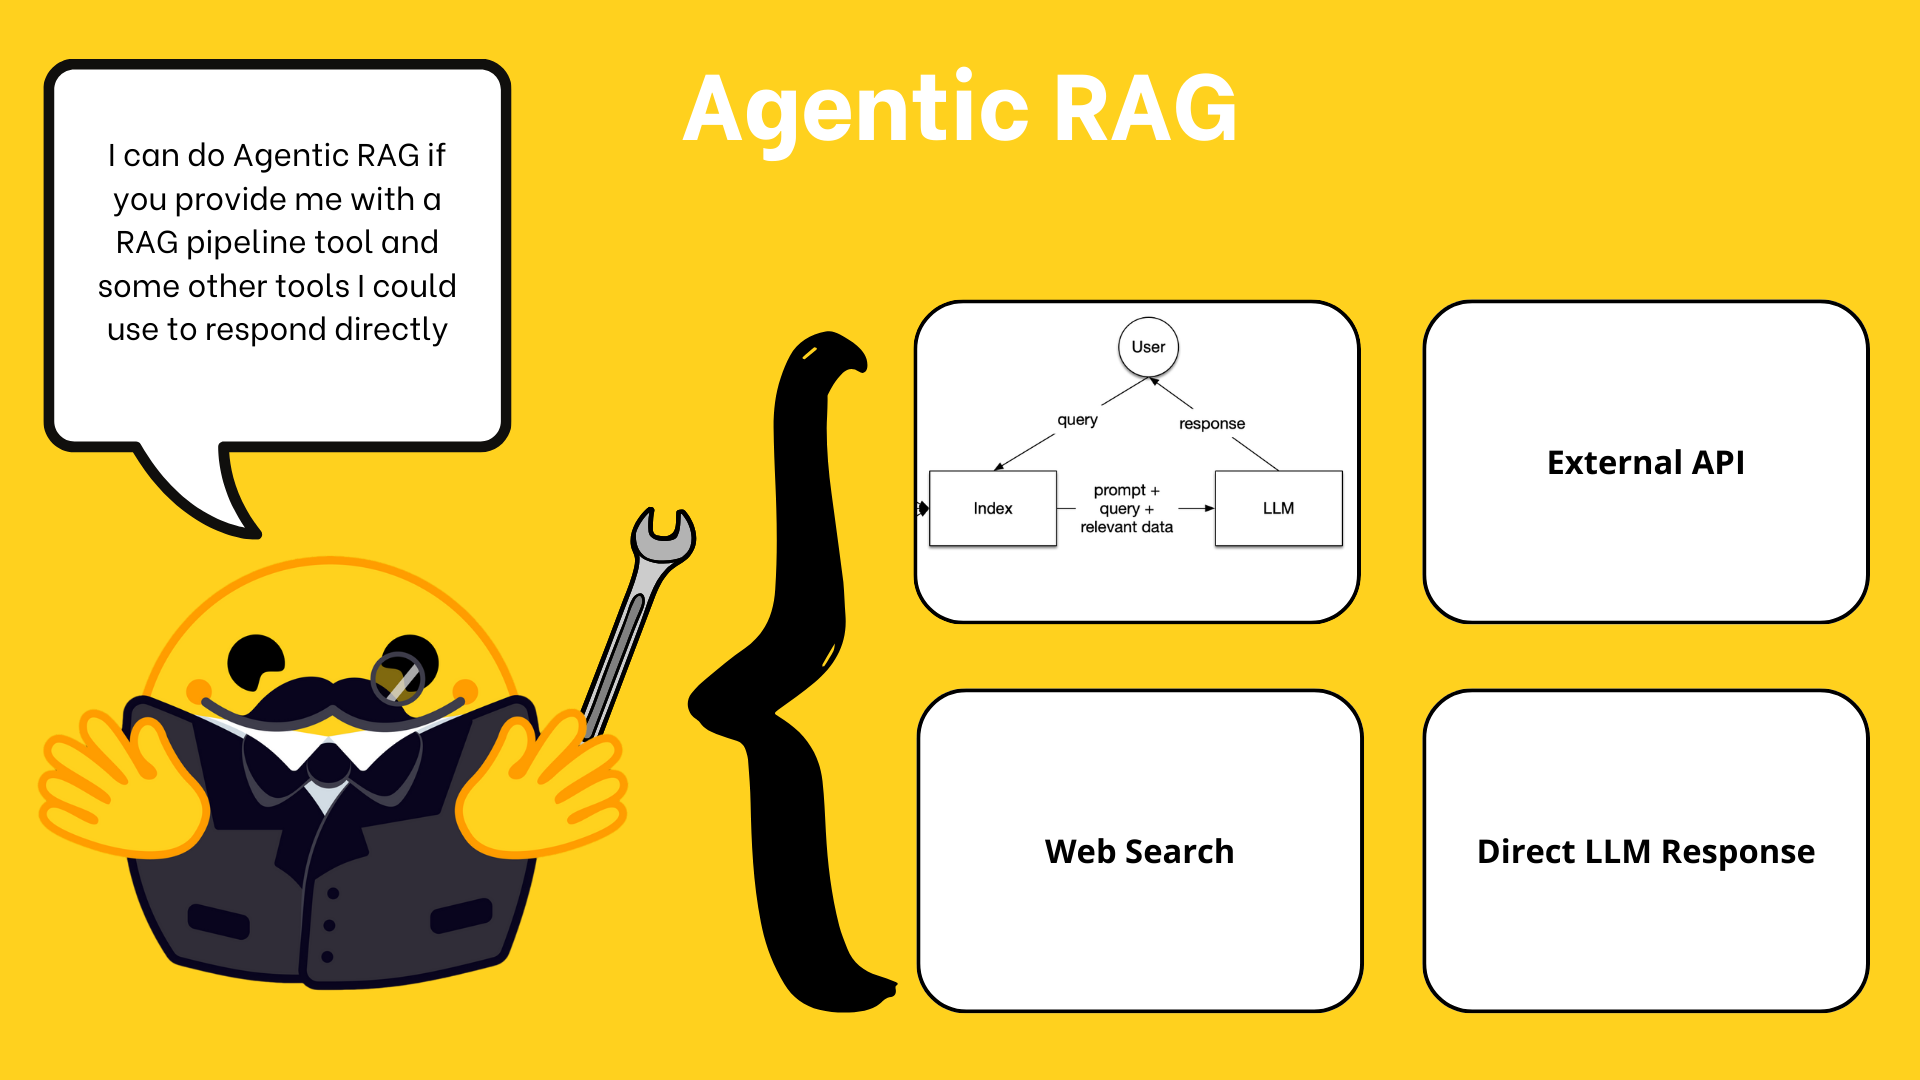

### [workflow](https://huggingface.co/learn/agents-course/ko/unit2/llama-index/workflows)

In [39]:
# !pip install llama-index-utils-workflow

In [40]:
from llama_index.core.workflow import StartEvent, StopEvent, Workflow, step

class MyWorkflow(Workflow):
    @step
    async def my_step(self, ev: StartEvent) -> StopEvent:
        # 여기서 무언가 수행
        return StopEvent(result="안녕하세요, 세계!")


w = MyWorkflow(timeout=10, verbose=False)
result = await w.run()

In [41]:
from llama_index.core.workflow import Event

class ProcessingEvent(Event):
    intermediate_result: str

class MultiStepWorkflow(Workflow):
    @step
    async def step_one(self, ev: StartEvent) -> ProcessingEvent:
        # 초기 데이터 처리
        return ProcessingEvent(intermediate_result="1단계 완료")

    @step
    async def step_two(self, ev: ProcessingEvent) -> StopEvent:
        # 중간 결과 사용
        final_result = f"처리 완료: {ev.intermediate_result}"
        return StopEvent(result=final_result)

w = MultiStepWorkflow(timeout=10, verbose=False)
result = await w.run()
result

'처리 완료: 1단계 완료'

In [49]:
from llama_index.core.workflow import Event
import random


class ProcessingEvent(Event):
    intermediate_result: str


class LoopEvent(Event):
    loop_output: str


class MultiStepWorkflow(Workflow):
    @step
    async def step_one(self, ev: StartEvent | LoopEvent) -> ProcessingEvent | LoopEvent:
        if random.randint(0, 1) == 0:
            print("나쁜 일이 발생했습니다")
            return LoopEvent(loop_output="1단계로 돌아갑니다.")
        else:
            print("좋은 일이 발생했습니다")
            return ProcessingEvent(intermediate_result="첫 번째 단계 완료.")

    @step
    async def step_two(self, ev: ProcessingEvent) -> StopEvent:
        # 중간 결과 사용
        final_result = f"처리 완료: {ev.intermediate_result}"
        return StopEvent(result=final_result)


w = MultiStepWorkflow(verbose=False)
result = await w.run()
result

나쁜 일이 발생했습니다
좋은 일이 발생했습니다


'처리 완료: 첫 번째 단계 완료.'

In [56]:
result = await w.run()
result

나쁜 일이 발생했습니다
나쁜 일이 발생했습니다
나쁜 일이 발생했습니다
좋은 일이 발생했습니다


'처리 완료: 첫 번째 단계 완료.'

In [51]:
result = await w.run()
result

좋은 일이 발생했습니다


'처리 완료: 첫 번째 단계 완료.'

In [52]:
from llama_index.utils.workflow import draw_all_possible_flows

draw_all_possible_flows(w, "flow.html")

flow.html


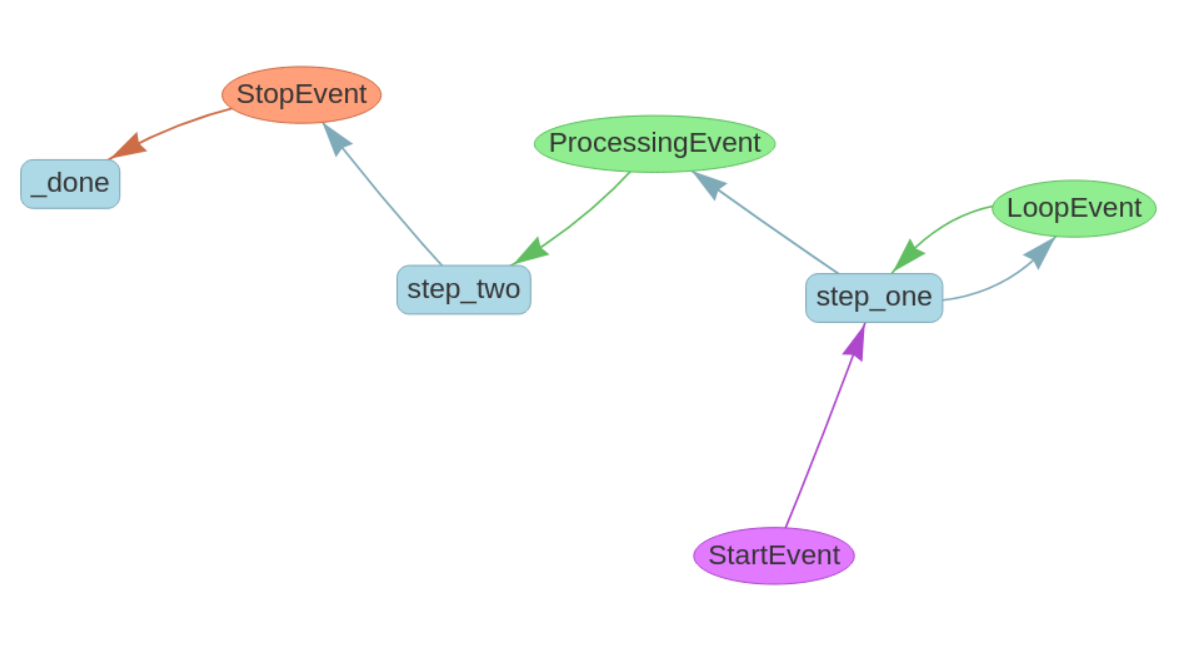

In [ ]:
from llama_index.core.workflow import Context, StartEvent, StopEvent


@step
async def query(self, ctx: Context, ev: StartEvent) -> StopEvent:
    # 컨텍스트에 쿼리 저장
    await ctx.store.set("query", "프랑스의 수도는 무엇인가요?")

    # 컨텍스트와 이벤트로 무언가 수행
    val = ...

    # 컨텍스트에서 쿼리 검색
    query = await ctx.store.get("query")

    return StopEvent(result=val)

In [58]:
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI
from llama_index.core.agent.workflow import AgentWorkflow, ReActAgent

# 샘플 툴 정의 -- 타입 어노테이션, 함수 이름, 독스트링이 모두 파싱된 스키마에 포함됩니다!
def add(a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    return a + b

def subtract(a: int, b: int) -> int:
    """두 숫자를 뺍니다."""
    return a - b

def multiply(a: int, b: int) -> int:
    """두 정수를 곱하고 결과 정수를 반환합니다"""
    return a * b

def divide(a: int, b: int) -> float:
    '''두 정수를 나누고 결과를 반환합니다'''
    return a / b

# llm 초기화
llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen3-Coder-30B-A3B-Instruct",
                              provider = 'auto')

# 에이전트 초기화
calculator_agent = ReActAgent(
    name="calculator",
    description="기본 산술 연산을 수행합니다.",
    system_prompt="당신은 계산기 어시스턴트입니다. 산술 질문에는 반드시 도구를 사용하고 한국어로 답하세요.",
    tools=[multiply, divide, add, subtract],
    llm=llm,
    streaming=False,
)

agent = AgentWorkflow(
    agents=[calculator_agent],
    root_agent="calculator",
)

In [60]:
# 시스템 실행
response = await agent.run(user_msg="5와 3을 더할 수 있나요?")
response

AgentOutput(response=ChatMessage(role=<MessageRole.ASSISTANT: 'assistant'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='5와 3을 더하면 8입니다.')]), structured_response=None, current_agent_name='calculator', raw=ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content="Thought: I can answer without using any more tools. I'll use the user's language to answer\nAnswer: 5와 3을 더하면 8입니다.", reasoning=None, tool_call_id=None, tool_calls=[], refusal=None, annotations=None, audio=None, function_call=None, reasoning_content=None), logprobs=None, stop_reason=None, token_ids=None)], created=1780902033, id='chatcmpl-714633d0-9b95-4c66-968b-4c82dc10a761', model='qwen3-coder-30b-a3b-instruct', system_fingerprint=None, usage=ChatCompletionOutputUsage(completion_tokens=36, prompt_tokens=910, total_tokens=946, prompt_tokens_details=None), object='chat.completion', service_tier=None, prompt_logprob

In [61]:
# 시스템 실행
response = await agent.run(user_msg="5와 3과 7을 더할 수 있나요?")
response

AgentOutput(response=ChatMessage(role=<MessageRole.ASSISTANT: 'assistant'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='네, 5와 3과 7을 더할 수 있습니다. 그 결과는 15입니다.')]), structured_response=None, current_agent_name='calculator', raw=ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content="Thought: I can answer without using any more tools. I'll use the user's language to answer\nAnswer: 네, 5와 3과 7을 더할 수 있습니다. 그 결과는 15입니다.", reasoning=None, tool_call_id=None, tool_calls=[], refusal=None, annotations=None, audio=None, function_call=None, reasoning_content=None), logprobs=None, stop_reason=None, token_ids=None)], created=1780902081, id='chatcmpl-77a35a16-807c-411b-85ec-679c72adc5c7', model='qwen3-coder-30b-a3b-instruct', system_fingerprint=None, usage=ChatCompletionOutputUsage(completion_tokens=49, prompt_tokens=1021, total_tokens=1070, prompt_tokens_details=None), object='chat.comp

In [62]:
from llama_index.core.workflow import Context

# 몇 가지 툴 정의
async def add(ctx: Context, a: int, b: int) -> int:
    """두 숫자를 더합니다."""
    # 카운트 업데이트
    cur_state = await ctx.store.get("state")
    cur_state["num_fn_calls"] += 1
    await ctx.store.set("state", cur_state)

    return a + b

async def multiply(ctx: Context, a: int, b: int) -> int:
    """두 숫자를 곱합니다."""
    # 카운트 업데이트
    cur_state = await ctx.store.get("state")
    cur_state["num_fn_calls"] += 1
    await ctx.store.set("state", cur_state)

    return a * b

In [67]:
# 에이전트 초기화
calculator_agent = ReActAgent(
    name="calculator",
    description="기본 산술 연산을 수행합니다.",
    system_prompt="당신은 계산기 어시스턴트입니다. 산술 질문에는 반드시 도구를 사용하고 한국어로 답하세요.",
    tools=[multiply, divide, add, subtract],
    llm=llm,
    streaming=False,
)

workflow = AgentWorkflow(
    agents=[calculator_agent],
    root_agent="calculator",
    initial_state={"num_fn_calls":0},
    state_prompt='현재 상태: {state}. 사용자 메세지: {msg}'
)

In [68]:
ctx = Context(workflow)
response = await workflow.run(user_msg='5와 3과 7을 더할 수 있나요?', ctx=ctx)
response

AgentOutput(response=ChatMessage(role=<MessageRole.ASSISTANT: 'assistant'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='네, 5와 3과 7을 더하면 15가 됩니다.')]), structured_response=None, current_agent_name='calculator', raw=ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content="Thought: I can answer without using any more tools. I'll use the user's language to answer\nAnswer: 네, 5와 3과 7을 더하면 15가 됩니다.", reasoning=None, tool_call_id=None, tool_calls=[], refusal=None, annotations=None, audio=None, function_call=None, reasoning_content=None), logprobs=None, stop_reason=None, token_ids=None)], created=1780902369, id='chatcmpl-0420a0ec-b093-41f4-9ad1-45824fe4462f', model='qwen3-coder-30b-a3b-instruct', system_fingerprint=None, usage=ChatCompletionOutputUsage(completion_tokens=45, prompt_tokens=1020, total_tokens=1065, prompt_tokens_details=None), object='chat.completion', service_tier=

In [69]:
# 상태를 꺼내서 검사
state = await ctx.store.get("state")
print(state["num_fn_calls"])

2
